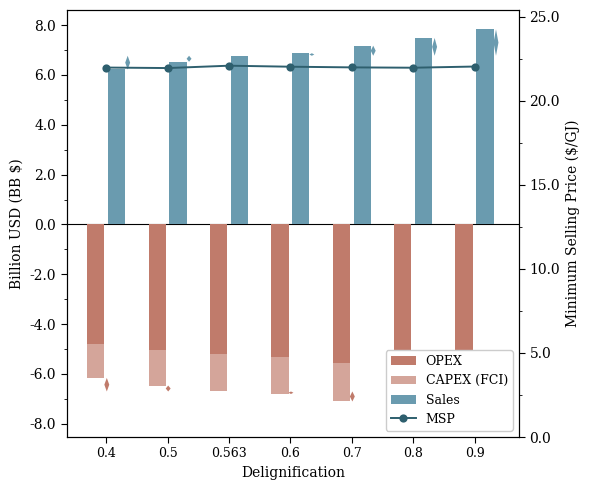

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon as MplPolygon
import numpy as np

# Data (MM$ → BB$)
delignification = [0.4, 0.5, 0.563, 0.60, 0.70, 0.80, 0.90]
opex  = [v/1000 for v in [4797.17, 5050.58, 5218.321024, 5309.862235, 5562.980258, 5816.81811,  6076.374523]]
capex = [v/1000 for v in [1361.44, 1415.29, 1485.35, 1494.672728, 1542.900722,1597.243003, 1676.443406]]
sales = [v/1000 for v in [6220.52, 6530.23, 6771.141244, 6872.456452, 7176.014355, 7486.670278, 7828.978816]]
msp   = [21.97, 21.94, 22.08, 22.02, 21.98,  21.96,  22.03]

x = np.arange(len(delignification))
bar_width = 0.28
gap = 0.03


plt.rc('font',family='Arial')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

color_opex  = '#C07B6B'
color_capex = '#D4A59A'
color_sales = '#6A9BAF'
color_msp   = '#2E5F6E'

fig, ax1 = plt.subplots(figsize=(6, 5))

# --- Bars ---
ax1.bar(x - bar_width/2 - gap, [-v for v in opex],  width=bar_width, color=color_opex,  label='OPEX', zorder=3)
ax1.bar(x - bar_width/2 - gap, [-v for v in capex], width=bar_width, color=color_capex, label='CAPEX (FCI)',
        bottom=[-v for v in opex], zorder=3)
ax1.bar(x + bar_width/2 + gap, sales, width=bar_width, color=color_sales, label='Sales', zorder=3)

# Zero line
ax1.axhline(0, color='black', linewidth=0.8)

# --- Filled rhombus markers showing delta from 0.563 reference ---
ref_idx   = delignification.index(0.563)
ref_sales = sales[ref_idx]
ref_cost  = -(opex[ref_idx] + capex[ref_idx])

dw = 0.04  # horizontal half-width of each rhombus (fixed)

def add_rhombus(ax, lx, cy, hh, color):
    cx = lx + dw
    verts = [(cx, cy + hh), (cx + dw, cy), (cx, cy - hh), (lx, cy)]
    ax.add_patch(MplPolygon(verts, closed=True, facecolor=color, edgecolor='none', zorder=5))

for i in range(len(delignification)):
    if i == ref_idx:
        continue
    # Sales rhombus: right of sales bar, height = |delta_sales|
    lx_s  = x[i] + bar_width + gap
    cy_s  = (ref_sales + sales[i]) / 2
    hh_s  = abs(sales[i] - ref_sales) / 2
    add_rhombus(ax1, lx_s, cy_s, hh_s, color_sales)

    # Cost rhombus: right of cost bar, height = |delta_cost|
    lx_c  = x[i] - gap
    bar_bot = -(opex[i] + capex[i])
    cy_c  = (ref_cost + bar_bot) / 2
    hh_c  = abs(bar_bot - ref_cost) / 2
    add_rhombus(ax1, lx_c, cy_c, hh_c, color_opex)

# Spines
for s in ['bottom', 'left', 'right', 'top']:
    ax1.spines[s].set_linewidth(0.8)

# Y axis: keep actual sign (negative shows as negative)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, _: f'{val:.1f}'))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax1.xaxis.set_minor_locator(ticker.NullLocator())
ax1.set_ylabel('Billion USD (BB $)', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels([str(d) for d in delignification], fontsize=9)
ax1.set_xlabel('Delignification', fontsize=10)
ax1.tick_params(which='both', direction='out', top=False, right=False)

# --- MSP line on ax2, starting from 0 ---
ax2 = ax1.twinx()
ax2.plot(x, msp, color=color_msp, linewidth=1.4, marker='o', markersize=4.5,
         markerfacecolor=color_msp, markeredgewidth=1.4, markeredgecolor=color_msp,
         label='MSP', zorder=5)
ax2.set_ylabel('Minimum Selling Price ($/GJ)', fontsize=10)

ax2.spines['top'].set_linewidth(0.8)
ax2.spines['right'].set_linewidth(0.8)

# Start from 0, give some headroom above max
ax2.set_ylim(0, max(msp) * 1.15)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax2.tick_params(which='both', direction='out', top=False)

# --- Combined legend ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           frameon=True, framealpha=1, edgecolor='0.8',
           fontsize=9, loc='lower right')
plt.rcParams['svg.fonttype'] = 'none'
plt.tight_layout()
plt.savefig('delignification_chart_v2.svg', dpi=300, bbox_inches='tight')
plt.show()